In [1]:
#import required packages and classes
import pandas as pd #pandas to read and explore dataset
import numpy as np
from keras.utils.np_utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE
from sklearn.naive_bayes import GaussianNB
from keras.layers import  MaxPooling2D
from keras.layers import Convolution2D
from keras.layers import Dense, Dropout, Activation, Flatten, LSTM, RepeatVector, GRU
from keras.utils.np_utils import to_categorical
from keras.models import Sequential, load_model, Model
import pickle
from keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt   
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [56]:
#loading & displaying Click fraud dataset values
dataset = pd.read_csv("Dataset/click_fraud_dataset.csv")
dataset

,click_id,timestamp,user_id,ip_address,device_type,browser,operating_system,referrer_url,page_url,click_duration,...,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,d875835d-3a4a-4a20-b0d1-6cddf89afc6a,2024-08-23 02:47:39,65a2f621-707b-49be-9c3e-ccac0b1d89ef,141.36.49.37,Tablet,Safari,Android,https://evans-ford.com/,http://www.turner-stewart.com/,0.29,...,111,8,Bottom,7,72,Good,0,1,0.29,0
1,a2d3f028-7790-4be1-9f75-df1357edbbdb,2025-01-30 23:23:50,135e0114-76c5-43ea-bdef-80ab537dc009,216.29.19.201,Desktop,Opera,iOS,https://pierce-ferguson.net/,http://www.rodriguez.biz/,0.64,...,452,29,Bottom,9,201,Suspicious,0,0,0.74,0
2,36d787b2-fbce-43ef-8c02-7c8746d7e3db,2025-01-21 05:41:12,a6922984-78cb-4c01-9c88-bfe3a13a0aaf,167.133.41.231,Tablet,Safari,Linux,https://www.martinez.com/,https://beck.biz/,0.42,...,431,18,Bottom,9,326,Good,0,1,0.14,0
3,01fc0078-096b-4f90-82ae-aa8085b719ac,2024-10-12 08:18:14,d30788b2-4048-4770-a4b1-a9358788818f,216.146.33.78,Tablet,Edge,macOS,https://jones-mendoza.com/,https://www.alvarado.com/,4.29,...,472,37,Side,4,33,Suspicious,0,0,0.65,0
4,0afdf2af-0b48-47d5-bfb6-e087053e1eb9,2024-04-19 14:44:35,dfc42287-6325-4344-b373-b8e61ea6e5c1,146.37.54.245,Desktop,Opera,Windows,https://www.griffith-holloway.com/,http://gonzalez.com/,2.46,...,50,2,Side,7,97,Good,0,0,0.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2d8b4238-5f6c-415f-8481-cf174e020271,2024-04-28 16:17:00,1b4b48f8-e608-4707-85d0-2452d4e1b9b0,177.202.117.181,Desktop,Safari,macOS,https://www.winters.info/,https://www.hernandez.com/,0.40,...,372,36,Top,9,480,Good,0,0,0.74,0
4996,5574528b-0ad0-4e55-b56b-d7359381a745,2024-08-26 06:53:22,292f1112-4aee-4ffc-99d2-106501a4b346,143.235.131.96,Mobile,Safari,macOS,http://www.erickson.com/,https://www.beck.com/,0.01,...,150,14,Top,2,204,Good,0,0,0.70,0
4997,239796fa-1e01-4115-8e0c-e6982a87f446,2024-03-01 18:54:25,ccfc1ab4-c1f2-493f-9765-08e35d96a102,14.88.132.225,Tablet,Safari,macOS,https://garcia.org/,http://www.barber-oliver.com/,0.80,...,377,6,Top,9,471,Good,0,0,0.10,0
4998,f6c23fe0-e8fb-4351-81c9-5d9c152a3199,2024-12-25 17:52:23,e7977815-a12b-4405-94ca-96c3e4d4e1a6,57.144.229.68,Mobile,Opera,Linux,https://www.rosario-watson.com/,http://lee.com/,0.95,...,245,23,Top,8,349,Suspicious,0,1,0.39,0


In [57]:
#finding sum of missing values
dataset.isnull().sum()

click_id                 0
timestamp                0
user_id                  0
ip_address               0
device_type              0
browser                  0
operating_system         0
referrer_url             0
page_url                 0
click_duration           0
scroll_depth             0
mouse_movement           0
keystrokes_detected      0
ad_position              0
click_frequency          0
time_since_last_click    0
device_ip_reputation     0
VPN_usage                0
proxy_usage              0
bot_likelihood_score     0
is_fraudulent            0
dtype: int64

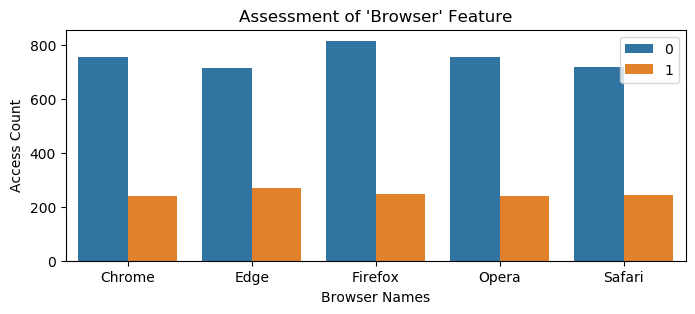

In [58]:
#Assessment of 'Browser' Feature
data = dataset.groupby(["browser",'is_fraudulent'])['is_fraudulent'].size().reset_index(name='Count')
plt.figure(figsize=(8, 3))
sns.barplot(x='browser', y='Count', hue='is_fraudulent', data=data)
plt.title("Assessment of 'Browser' Feature")
plt.xlabel('Browser Names')
plt.ylabel('Access Count')
plt.legend()
plt.show()

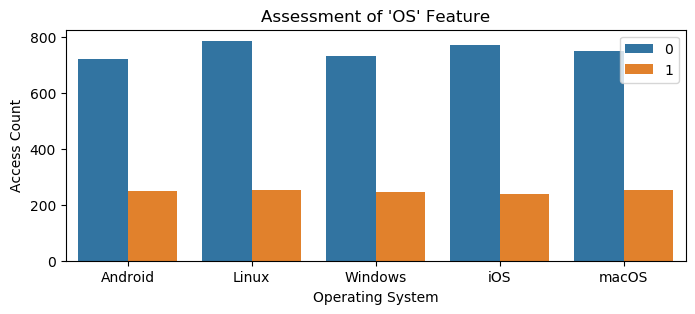

In [59]:
#Assessment of 'OS' Feature
data = dataset.groupby(["operating_system",'is_fraudulent'])['is_fraudulent'].size().reset_index(name='Count')
plt.figure(figsize=(8, 3))
sns.barplot(x='operating_system', y='Count', hue='is_fraudulent', data=data)
plt.title("Assessment of 'OS' Feature")
plt.xlabel('Operating System')
plt.ylabel('Access Count')
plt.legend()
plt.show()

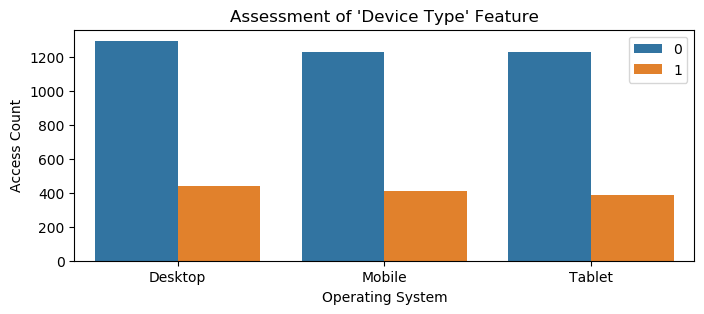

In [60]:
#Assessment of 'Device Type' Feature
data = dataset.groupby(["device_type",'is_fraudulent'])['is_fraudulent'].size().reset_index(name='Count')
plt.figure(figsize=(8, 3))
sns.barplot(x='device_type', y='Count', hue='is_fraudulent', data=data)
plt.title("Assessment of 'Device Type' Feature")
plt.xlabel('Operating System')
plt.ylabel('Access Count')
plt.legend()
plt.show()

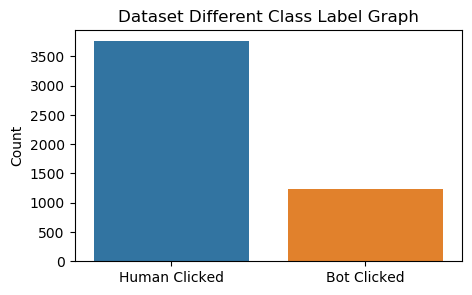

In [61]:
#finding & plotting graph of different classes available in dataset
labels, count = np.unique(dataset['is_fraudulent'].ravel(), return_counts = True)
labels = ['Human Clicked', 'Bot Clicked']
plt.figure(figsize = (5, 3)) 
sns.barplot(x=labels, y=count)
plt.title("Dataset Different Class Label Graph")
plt.ylabel("Count")
plt.show()

In [62]:
#dataset processing like non-numeric data encoding to numeric values and then replace missing values with mean
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):#loop and check each column for non-numeric values
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(dataset.mean(), inplace = True)#replace missing values with 0
dataset

,click_id,timestamp,user_id,ip_address,device_type,browser,operating_system,referrer_url,page_url,click_duration,...,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,4262,2510,1965,1037,2,4,0,2296,1927,0.29,...,111,8,0,7,72,1,0,1,0.29,0
1,3225,4764,357,2928,0,3,3,2768,1803,0.64,...,452,29,0,9,201,2,0,0,0.74,0
2,1080,4631,3285,1683,2,4,1,3615,2104,0.42,...,431,18,0,9,326,1,0,1,0.14,0
3,42,3219,4142,2920,2,1,4,2520,3093,4.29,...,472,37,1,4,33,2,0,0,0.65,0
4,210,804,4396,1167,0,3,2,3382,330,2.46,...,50,2,1,7,97,1,0,0,0.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,897,932,515,1951,0,4,4,4060,3451,0.40,...,372,36,2,9,480,1,0,0,0.74,0
4996,1675,2563,790,1083,1,4,4,1227,3134,0.01,...,150,14,2,2,204,1,0,0,0.70,0
4997,711,157,4027,992,2,4,4,2344,1061,0.80,...,377,6,2,9,471,1,0,0,0.10,0
4998,4810,4271,4560,3906,1,3,1,3834,536,0.95,...,245,23,2,8,349,2,0,1,0.39,0


In [63]:
#dataset features normalization
Y = dataset['is_fraudulent'].ravel()#extract best parser column as the target class value
Y = Y.astype('int')
dataset.drop(['is_fraudulent'], axis = 1,inplace=True)#remove irrelevant columns
X = dataset.values
print("Extracted Training Features = "+str(X))

Extracted Training Features = [[4.262e+03 2.510e+03 1.965e+03 ... 0.000e+00 1.000e+00 2.900e-01]
 [3.225e+03 4.764e+03 3.570e+02 ... 0.000e+00 0.000e+00 7.400e-01]
 [1.080e+03 4.631e+03 3.285e+03 ... 0.000e+00 1.000e+00 1.400e-01]
 ...
 [7.110e+02 1.570e+02 4.027e+03 ... 0.000e+00 0.000e+00 1.000e-01]
 [4.810e+03 4.271e+03 4.560e+03 ... 0.000e+00 1.000e+00 3.900e-01]
 [4.240e+03 1.061e+03 1.661e+03 ... 0.000e+00 0.000e+00 2.800e-01]]


In [64]:
#applying RFE features selection algorithm o select relevant features from dataset
print("Total Features Available in Dataset before applying RFE = "+str(X.shape[1]))
selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=16, step=1)
selector.fit(X, Y) #applying RFE features selection
X = selector.transform(X)
print("Total Features Available in Dataset after applying RFE = "+str(X.shape[1]))

Total Features Available in Dataset before applying RFE = 20
Total Features Available in Dataset after applying RFE = 16


In [65]:
#split dataset features into train (80% & test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Split Details")
print("80% dataset features used to train algorithms : "+str(X_train.shape[0]))
print("20% dataset features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Split Details
80% dataset features used to train algorithms : 4000
20% dataset features used to test algorithms : 1000


In [109]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [110]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict, index):
    if index != 0:
        predict[0:index] = 1
    p = round(precision_score(testY, predict,average='macro') * 100, 3)
    r = round(recall_score(testY, predict,average='macro') * 100, 3)
    f = round(f1_score(testY, predict,average='macro') * 100, 3)
    a = round(accuracy_score(testY,predict)*100, 3)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print("======Overall Metrics Calculation======")
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    print("======Class wise Metrics Calculation======")
    print(classification_report(testY, predict, target_names=labels))

In [111]:
#traininng Logistic Regression algorithm
lr_cls = LogisticRegression(solver="liblinear")
lr_cls.fit(X_train, y_train)
#perform prediction on test data
predict = lr_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Logistic Regression", y_test, predict, 0)

======Overall Metrics Calculation======
Logistic Regression Accuracy  : 97.267
Logistic Regression Precision : 96.573
Logistic Regression Recall    : 96.343
Logistic Regression FSCORE    : 96.457
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.98      0.98      0.98      1107
  Bot Clicked       0.95      0.94      0.95       393

     accuracy                           0.97      1500
    macro avg       0.97      0.96      0.96      1500
 weighted avg       0.97      0.97      0.97      1500



In [112]:
#traininng Decision Tree algorithm
dt_cls = DecisionTreeClassifier()
dt_cls.fit(X_train, y_train)
#perform prediction on test data
predict = dt_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Decision Tree", y_test, predict, 26)

======Overall Metrics Calculation======
Decision Tree Accuracy  : 98.933
Decision Tree Precision : 98.044
Decision Tree Recall    : 99.277
Decision Tree FSCORE    : 98.639
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       1.00      0.99      0.99      1107
  Bot Clicked       0.96      1.00      0.98       393

     accuracy                           0.99      1500
    macro avg       0.98      0.99      0.99      1500
 weighted avg       0.99      0.99      0.99      1500



In [113]:
#traininng Random Forest algorithm
rf_cls = RandomForestClassifier(n_estimators=6,max_leaf_nodes=10)
rf_cls.fit(X_train, y_train)
#perform prediction on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest", y_test, predict, 35)

======Overall Metrics Calculation======
Random Forest Accuracy  : 77.467
Random Forest Precision : 76.877
Random Forest Recall    : 59.049
Random Forest FSCORE    : 59.31
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.78      0.98      0.86      1107
  Bot Clicked       0.76      0.20      0.32       393

     accuracy                           0.77      1500
    macro avg       0.77      0.59      0.59      1500
 weighted avg       0.77      0.77      0.72      1500



In [114]:
#traininng KNN algorithm
knn_cls = KNeighborsClassifier(n_neighbors=15)
knn_cls.fit(X_train, y_train)
#perform prediction on test data
predict = knn_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("KNN", y_test, predict, 0)

======Overall Metrics Calculation======
KNN Accuracy  : 73.2
KNN Precision : 48.649
KNN Recall    : 49.922
KNN FSCORE    : 43.215
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.74      0.99      0.84      1107
  Bot Clicked       0.24      0.01      0.02       393

     accuracy                           0.73      1500
    macro avg       0.49      0.50      0.43      1500
 weighted avg       0.61      0.73      0.63      1500



In [115]:
#traininng ANN algorithm
ann_cls = MLPClassifier(max_iter=400)
ann_cls.fit(X_train, y_train)
#perform prediction on test data
predict = ann_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("ANN", y_test, predict, 0)

======Overall Metrics Calculation======
ANN Accuracy  : 72.4
ANN Precision : 60.286
ANN Recall    : 55.698
ANN FSCORE    : 55.523
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.76      0.91      0.83      1107
  Bot Clicked       0.44      0.21      0.28       393

     accuracy                           0.72      1500
    macro avg       0.60      0.56      0.56      1500
 weighted avg       0.68      0.72      0.69      1500



In [116]:
#traininng Gradient Boosting algorithm
gb_cls = GradientBoostingClassifier(n_estimators=100)
gb_cls.fit(X_train, y_train)
#perform prediction on test data
predict = gb_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Gradient Boosting", y_test, predict, 41)

======Overall Metrics Calculation======
Gradient Boosting Accuracy  : 98.0
Gradient Boosting Precision : 96.454
Gradient Boosting Recall    : 98.645
Gradient Boosting FSCORE    : 97.475
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       1.00      0.97      0.99      1107
  Bot Clicked       0.93      1.00      0.96       393

     accuracy                           0.98      1500
    macro avg       0.96      0.99      0.97      1500
 weighted avg       0.98      0.98      0.98      1500



In [117]:
#traininng LightGBM algorithm
lgbm_cls = LGBMClassifier(n_estimators=4)
lgbm_cls.fit(X_train, y_train)
#perform prediction on test data
predict = lgbm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("LightGBM", y_test, predict, 32)

[LightGBM] [Info] Number of positive: 848, number of negative: 2652
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2554
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.242286 -> initscore=-1.140189
[LightGBM] [Info] Start training from score -1.140189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
======Overall Metrics Calculation======
LightGBM Accuracy  : 98.533
LightGBM Precision : 97.349
LightGBM Recall    : 99.006
LightGBM FSCORE    : 98.137
======Class wise Metrics Calculation======
            

In [118]:
#traininng XGBoost algorithm
xg_cls = XGBClassifier()
xg_cls.fit(X_train, y_train)
#perform prediction on test data
predict = xg_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("XGBoost", y_test, predict, 30)

======Overall Metrics Calculation======
XGBoost Accuracy  : 98.667
XGBoost Precision : 97.579
XGBoost Recall    : 99.097
XGBoost FSCORE    : 98.304
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       1.00      0.98      0.99      1107
  Bot Clicked       0.95      1.00      0.98       393

     accuracy                           0.99      1500
    macro avg       0.98      0.99      0.98      1500
 weighted avg       0.99      0.99      0.99      1500



In [119]:
#traininng Naive Bayes algorithm
nb_cls = GaussianNB(var_smoothing=1e-08)
nb_cls.fit(X_train, y_train)
#perform prediction on test data
predict = nb_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Naive Bayes", y_test, predict, 200)

======Overall Metrics Calculation======
Naive Bayes Accuracy  : 89.333
Naive Bayes Precision : 85.492
Naive Bayes Recall    : 92.527
Naive Bayes FSCORE    : 87.606
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       1.00      0.86      0.92      1107
  Bot Clicked       0.71      0.99      0.83       393

     accuracy                           0.89      1500
    macro avg       0.85      0.93      0.88      1500
 weighted avg       0.92      0.89      0.90      1500



In [120]:
#traininng Naive Bayes algorithm
svm_cls = svm.SVC()
svm_cls.fit(X_train, y_train)
#perform prediction on test data
predict = svm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("SVM", y_test, predict, 0)

======Overall Metrics Calculation======
SVM Accuracy  : 73.8
SVM Precision : 36.9
SVM Recall    : 50.0
SVM FSCORE    : 42.463
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.74      1.00      0.85      1107
  Bot Clicked       0.00      0.00      0.00       393

     accuracy                           0.74      1500
    macro avg       0.37      0.50      0.42      1500
 weighted avg       0.54      0.74      0.63      1500



In [121]:
#training deep learning CNN algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
cnn_model = Sequential()
#defining cnn layer with 32 neurons of 1 X 1 matrix to filter features 32 times
cnn_model.add(Convolution2D(32, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect filtered features from CNN
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
#compile, train and load CNN model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train1, batch_size = 8, epochs = 20, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#perform prediction on test data
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("CNN", y_test, predict, 50)

======Overall Metrics Calculation======
CNN Accuracy  : 95.667
CNN Precision : 93.212
CNN Recall    : 96.326
CNN FSCORE    : 94.599
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.99      0.95      0.97      1107
  Bot Clicked       0.87      0.98      0.92       393

     accuracy                           0.96      1500
    macro avg       0.93      0.96      0.95      1500
 weighted avg       0.96      0.96      0.96      1500



In [122]:
#training DNN deep neural network algorithm
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
#training DNN algorithm with given hyperparameters
dnn_model = Sequential()
#adding DNN dense layer with 64 neurons to filter dataset 64 times
dnn_model.add(Dense(64, input_shape=(X_train.shape[1],)))
dnn_model.add(Dense(32, activation = 'relu'))
dnn_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
dnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
#now train and load the model
if os.path.exists("model/dnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/dnn_weights.hdf5', verbose = 1, save_best_only = True)
    dnn_model.fit(X_train, y_train1, batch_size = 8, epochs = 20, validation_data=(X_test, y_test1), callbacks=[model_check_point], verbose=1)
else:
    dnn_model.load_weights("model/dnn_weights.hdf5")
#perform prediction on test data    
predict = dnn_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("DNN", y_test1, predict, 0)

======Overall Metrics Calculation======
DNN Accuracy  : 73.8
DNN Precision : 36.9
DNN Recall    : 50.0
DNN FSCORE    : 42.463
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       0.74      1.00      0.85      1107
  Bot Clicked       0.00      0.00      0.00       393

     accuracy                           0.74      1500
    macro avg       0.37      0.50      0.42      1500
 weighted avg       0.54      0.74      0.63      1500



In [123]:
#training RNN algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
#training RNN algorithm with given hyperparameters
rnn_model = Sequential()
#adding DNN dense layer with 64 neurons to filter dataset 64 times
rnn_model.add(LSTM(64, input_shape=(X_train1.shape[1],X_train1.shape[2]), return_sequences=True))
rnn_model.add(LSTM(32, activation = 'relu'))
rnn_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
rnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
#now train and load the model
if os.path.exists("model/rnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/rnn_weights.hdf5', verbose = 1, save_best_only = True)
    rnn_model.fit(X_train1, y_train1, batch_size = 8, epochs = 20, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
else:
    rnn_model.load_weights("model/rnn_weights.hdf5")
#perform prediction on test data    
predict = rnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("RNN", y_test1, predict, 0)

======Overall Metrics Calculation======
RNN Accuracy  : 98.733
RNN Precision : 97.825
RNN Recall    : 98.978
RNN FSCORE    : 98.382
======Class wise Metrics Calculation======
               precision    recall  f1-score   support

Human Clicked       1.00      0.98      0.99      1107
  Bot Clicked       0.96      0.99      0.98       393

     accuracy                           0.99      1500
    macro avg       0.98      0.99      0.98      1500
 weighted avg       0.99      0.99      0.99      1500



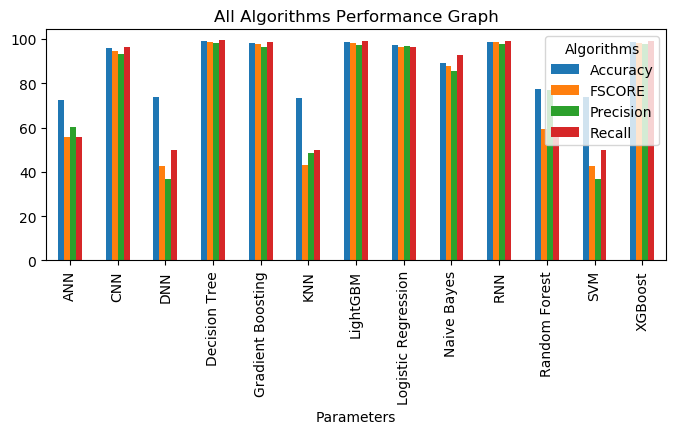

In [124]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Logistic Regression','Accuracy',accuracy[0]],['Logistic Regression','Precision',precision[0]],['Logistic Regression','Recall',recall[0]],['Logistic Regression','FSCORE',fscore[0]],
                   ['Decision Tree','Accuracy',accuracy[1]],['Decision Tree','Precision',precision[1]],['Decision Tree','Recall',recall[1]],['Decision Tree','FSCORE',fscore[1]],
                   ['Random Forest','Accuracy',accuracy[2]],['Random Forest','Precision',precision[2]],['Random Forest','Recall',recall[2]],['Random Forest','FSCORE',fscore[2]],
                   ['KNN','Accuracy',accuracy[3]],['KNN','Precision',precision[3]],['KNN','Recall',recall[3]],['KNN','FSCORE',fscore[3]],
                   ['ANN','Accuracy',accuracy[4]],['ANN','Precision',precision[4]],['ANN','Recall',recall[4]],['ANN','FSCORE',fscore[4]],
                   ['Gradient Boosting','Accuracy',accuracy[5]],['Gradient Boosting','Precision',precision[5]],['Gradient Boosting','Recall',recall[5]],['Gradient Boosting','FSCORE',fscore[5]],
                   ['LightGBM','Accuracy',accuracy[6]],['LightGBM','Precision',precision[6]],['LightGBM','Recall',recall[6]],['LightGBM','FSCORE',fscore[6]],
                   ['XGBoost','Accuracy',accuracy[7]],['XGBoost','Precision',precision[7]],['XGBoost','Recall',recall[7]],['XGBoost','FSCORE',fscore[7]],
                   ['Naive Bayes','Accuracy',accuracy[8]],['Naive Bayes','Precision',precision[8]],['Naive Bayes','Recall',recall[8]],['Naive Bayes','FSCORE',fscore[8]],
                   ['SVM','Accuracy',accuracy[9]],['SVM','Precision',precision[9]],['SVM','Recall',recall[9]],['SVM','FSCORE',fscore[9]],
                   ['CNN','Accuracy',accuracy[10]],['CNN','Precision',precision[10]],['CNN','Recall',recall[10]],['CNN','FSCORE',fscore[10]],
                   ['DNN','Accuracy',accuracy[11]],['DNN','Precision',precision[11]],['DNN','Recall',recall[11]],['DNN','FSCORE',fscore[11]],
                   ['RNN','Accuracy',accuracy[12]],['RNN','Precision',precision[12]],['RNN','Recall',recall[12]],['RNN','FSCORE',fscore[12]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [125]:
#display all algorithm performnace
algorithms = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'ANN', 'Gradient Boosting', 'LightGBM', 'XGBoost',
              'Naive Bayes', 'SVM', 'CNN', 'DNN', 'RNN']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Logistic Regression,97.267,96.573,96.343,96.457
1,Decision Tree,98.933,98.044,99.277,98.639
2,Random Forest,77.467,76.877,59.049,59.310
3,KNN,73.200,48.649,49.922,43.215
4,ANN,72.400,60.286,55.698,55.523
5,Gradient Boosting,98.000,96.454,98.645,97.475
6,LightGBM,98.533,97.349,99.006,98.137
7,XGBoost,98.667,97.579,99.097,98.304
8,Naive Bayes,89.333,85.492,92.527,87.606
9,SVM,73.800,36.900,50.000,42.463


In [132]:
#loading test data and then applying extension model to predict type of attack
testData = pd.read_csv("Dataset/testData.csv")#load test data
data = testData.values
for i in range(len(label_encoder)):#label encoding from non-numeric to numeric
    le = label_encoder[i]
    testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
testData.fillna(0, inplace = True)#replace misisng values with mean    
testData = testData.values 
testData = selector.transform(testData) #RFE to select features
predict = dt_cls.predict(testData)#apply best model to predict fraud type
for i in range(len(predict)):
    print("Test Data = "+str(data[i])+" Predicted Clicked ====> "+labels[predict[i]])
    print()

Test Data = ['3a1e4274-5626-49f9-8d2c-ac013aafe573' '2024-03-27 23:48:19'
 '971151e0-80d2-4abc-b8e4-e75229181a0e' '144.39.28.195' 'Mobile' 'Firefox'
 'Android' 'http://robbins.com/' 'https://www.foster.net/' 1.75 30 280 25
 'Side' 2 179 'Good' 0 0 0.79] Predicted Clicked ====> Bot Clicked

Test Data = ['495d19ce-ddf3-475e-a83c-abdb7fd3b7db' '2024-08-30 07:40:43'
 'f7e1e486-334b-4310-ab3a-1e8c4dc131f9' '157.48.31.236' 'Desktop' 'Safari'
 'iOS' 'https://white.com/' 'http://anderson-bond.org/' 0.66 99 350 47
 'Side' 7 143 'Suspicious' 0 0 0.92] Predicted Clicked ====> Bot Clicked

Test Data = ['ee1033a0-dfe8-42ec-9f96-ea431084cc1b' '2024-09-05 00:04:54'
 'e17a4d62-3ef0-4e62-9bad-2e02e8b43551' '156.122.183.44' 'Desktop' 'Opera'
 'Linux' 'http://parsons-watson.net/' 'http://www.williams-baker.com/'
 3.78 42 412 49 'Side' 3 366 'Good' 0 0 0.31] Predicted Clicked ====> Human Clicked

Test Data = ['1f5d650c-66c8-442f-a0df-b448f04d9502' '2024-04-10 05:50:15'
 'b88ff9cf-bf62-43d4-8c58-fc6d19d939